# Ejercicio: simular y visualizar PAS

Objetivo final: completar un cuaderno como este para generar todas las imágenes del PAS de las diapositivas, subirlo a vuestro perfil de GitHub, y compartirlo conmigo. (Para final de la semana que viene, fecha a concretar).

Sobre el uso de IA generativa / LLMs:
* Se os anima a usarla para desatascaros en pasos pequeños y muy concretos (que te explique cómo hacer la media por filas de una matriz; que te explique cómo funciona cierta función que el profesor ha mencionado etc.).
* Pero no tiene sentido usarla para pasos excesivamente grandes en los que perdéis el control de qué se está haciendo (por ejemplo, decirle que te genere las figuras directamente).
* El verdadero objetivo final es entender el proceso, desarrollar habilidades de planificación, y asimilar las estructuras de pensamiento matemático-computacional subyacentes. Estáis en etapa formativa, no en etapa productiva.
* Como posible control, yo podré convocaros en clase o tutoría para que me expliquéis cómo funciona vuestro código.
* Pero, al fin y al cabo, lo que más está en juego es vuestra formación: adquirir valor añadido (ser capaz de desarrollar unas estructuras mentales que os permitan resolver problemas complejos en el futuro, problemas que quizás sean diferentes a los que hay hoy día), o ser una pieza de poco valor añadido y fácilmente sustituible (un “usuario de IA”).

Se recomienda que avancéis de aquí al lunes. Probablemente le dediquemos lunes y martes, y ya después pasemos a otra cosa. Y tendréis que entregarlo a final de semana (fecha a concretar).

Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

---------------------------------------------------------------

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

## El núcleo: implementar una función para simular el PAS

Define una función `simular_PAS` que reciba tres argumentos:
* p: este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería $1-p$). Es un valor entre 0 y 1.
* n: el número de pasos a simular para cada trayectoria. Un número natural.
* reps: el número de trayectorias a simular. Un número natural.

La función debe devolver un array de numpy con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

Esqueleto de la función a construir (a completar por vosotros):

In [ ]:
# columnas son los instantes
# filas son las trayectorias
def simular_PAS(p,n,reps=1):
  # Input:
  # p: Explicar el significado del parámetro
  #    - El parámetro p es la probabilidad de dar un paso hacia arriba (+1), es un valor en [0,1].
  # n: Explicar el significado del parámetro
  #    - El parámetro n es el número total de datos en cada trayectoria
  # reps: Explicar el significado del parámetro
  #    - El parámetro reps significa el número de repeticiones - el número de trayectorias.
  # Output: matriz donde cada fila es una trayectoria completa empezando desde 0
  # output: Explicar el significado del output


  # PASO 1: Tenemos que generar los saltos aleatorios (+1, -1)
  # Usamos np.random.choice para crear una matriz.
  # [1,-1] es una lista con los valores que puede tomar en cada salto: 1 ó -1
  # size = tamaño, reps * n
  # p=[p, 1-p] probabilidades el primer valor probabilidad de que salga 1 y el segundo probabilidad de que salga -1
  # Shape resultante: (reps, n) -> reps filas (trayectorias), n columnas (pasos)
  pasos = np.random.choice([1, -1], size=(reps, n), p=[p, 1-p])

  # PASO 2: Calculamos la posición acumulada en el tiempo.
  # axis=1 indica que sumamos a lo largo de las columnas (el tiempo para cada trayectoria = cada fila).
  # Shape resultante: (reps, n)
  posiciones = np.cumsum(pasos, axis=1)

  # PASO 3: Insertamos el punto de partida (0) al inicio de cada trayectoria.
  # Creamos una columna de ceros de tamaño (reps, 1).
  comienzo = np.zeros((reps, 1))


  # PASO 4: Concatenamos horizontalmente los ceros con las posiciones acumuladas.
  # Shape final: (reps, n + 1) -> n+1 porque incluimos el instante t=0.
  output = np.hstack([comienzo, posiciones])

  #...  # Ir añadiendo comentarios con lo que se va haciendo. En particular, indicar el "shape" de los arrays que se vayan construyendo
  # (ver ejemplo en la última línea, en el "return").
  #...  # Minimizar el uso de bucles for, que son costosos computacionalmente como se ha visto en el tutorial de numpy (usar numpy en vez de bucles for). De hecho, esta función se debe hacer sin bucles for.

  return output  # Shape: (reps, n+1)


Primero piensa durante un rato cómo lo harías, e intenta completar la función. Si te quedas atrancado/a, puedes mirar la pista de abajo. **Importante**: lo fundamental de la frase anterior es "*si te quedas atrancado/a*", es decir, debes pensarlo un rato por tu cuenta. De lo contrario, si vas directo a la solución, no se produce ningún aprendizaje y no te sirve de nada.

----------------------------------------

Pista:

En principio, uno podría pensar en incluir dos bucles for:
* uno para iterar sobre las diferentes trayectorias que queremos generar (`reps`),
* otro para iterar sobre los diferentes pasos dentro de cada trayectoria (`n`).

Puedes eliminar ambos bucles construyendo un array de numpy de shape `(reps, n)` que, en cada posición, contenga un $1$ con probabilidad $p$ (y $-1$ con probabilidad $1-p$). Para esto, piensa en usar `np.random.rand` o `np.random.choice`.

Y trabajar ahora con ese array usando herramientas de numpy (piensa qué necesitas hacer con ese array, y busca en internet/LLM herramientas de numpy que hagan eso).


## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 16 ($p=0.5$), 17 ($p=0.6$) y 18 ($p=0.4$) del tema 1.

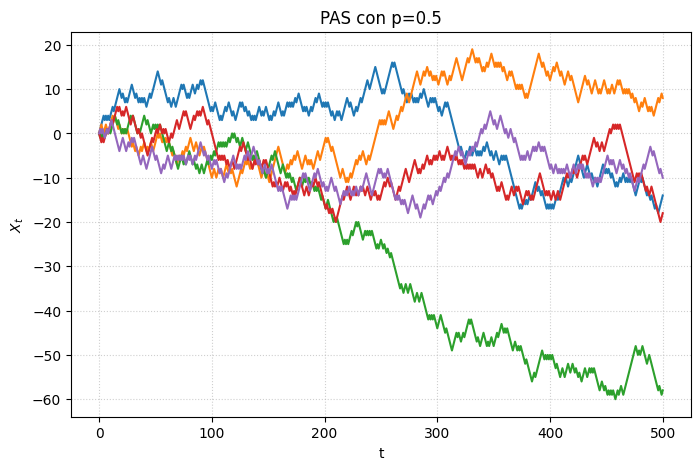

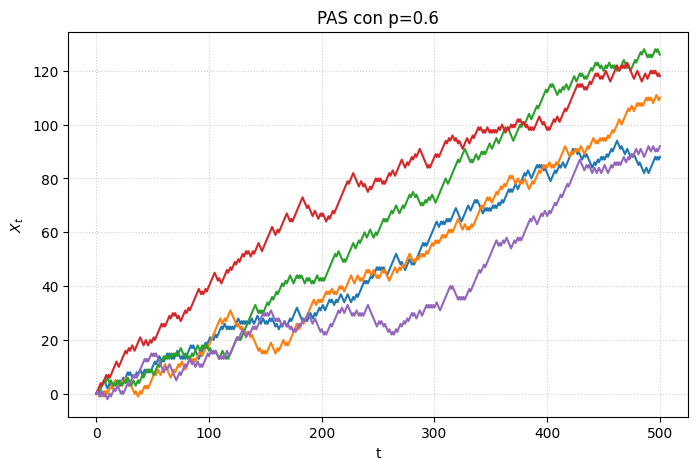

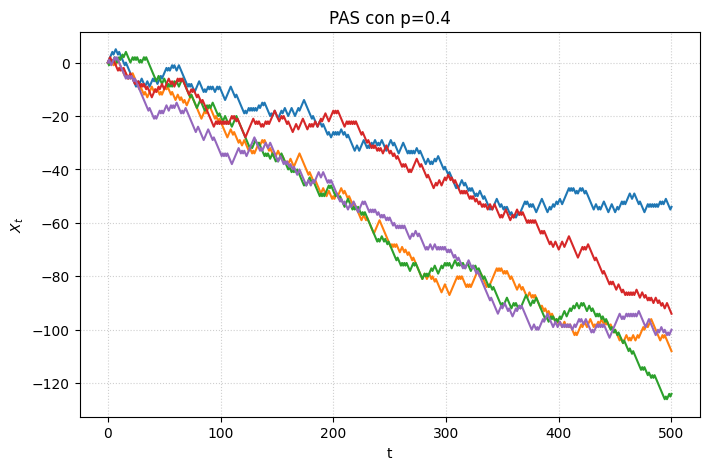

In [ ]:


# Parámetros de la simulación ---
n_pasos = 500  # Duración
p_val = 0.6    # Paseo simétrico

n_reps = 5   # Vamos a ver 10 trayectorias

# --- Llamada a la función ---
datos = simular_PAS(p_val, n_pasos, n_reps)
# --- Visualización 1: Diapositivas 16, 17 y 18 ---
escenarios_p = [0.5, 0.6, 0.4]
n_pasos = 500
n_reps = 5 # Según las diapositivas, se muestran 5 trayectorias

## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

# Escribir código para crear las imágenes de las diapositivas 16 ($p=0.5$), 17 ($p=0.6$) y 18 ($p=0.4$) del tema 1.
for p in escenarios_p:
    datos = simular_PAS(p, n_pasos, n_reps)

    plt.figure(figsize=(8, 5))
    plt.plot(datos.T, lw=1.5)
    plt.title(f'PAS con p={p}')
    plt.xlabel('t')
    plt.ylabel('$X_t$')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()


## Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 30 ($p=0.5$), 31 ($p=0.75$), 32 ($p=0.95$) del tema 1.

Para el sombreado de las imágenes, que tiene amplitud $\pm$ 1 o 2 veces la desviación típica, busca en internet/LLM qué función de matplotlib te permite hacerlo.



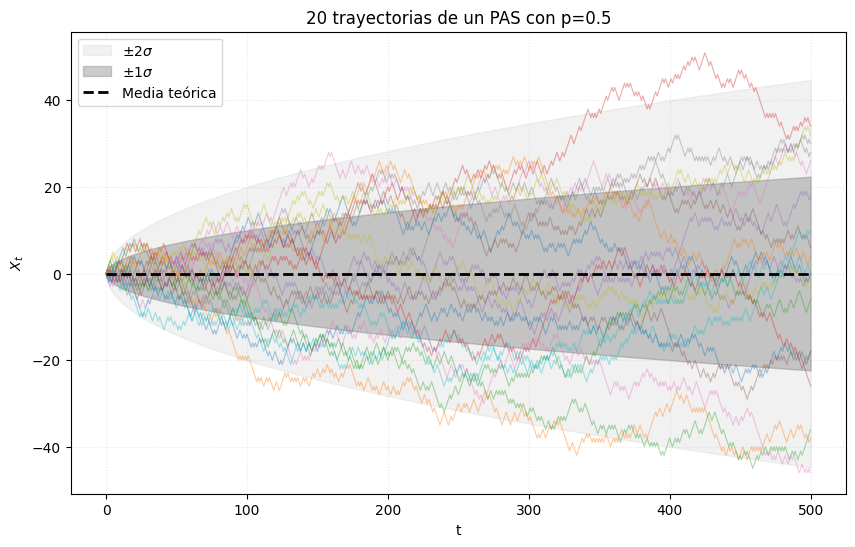

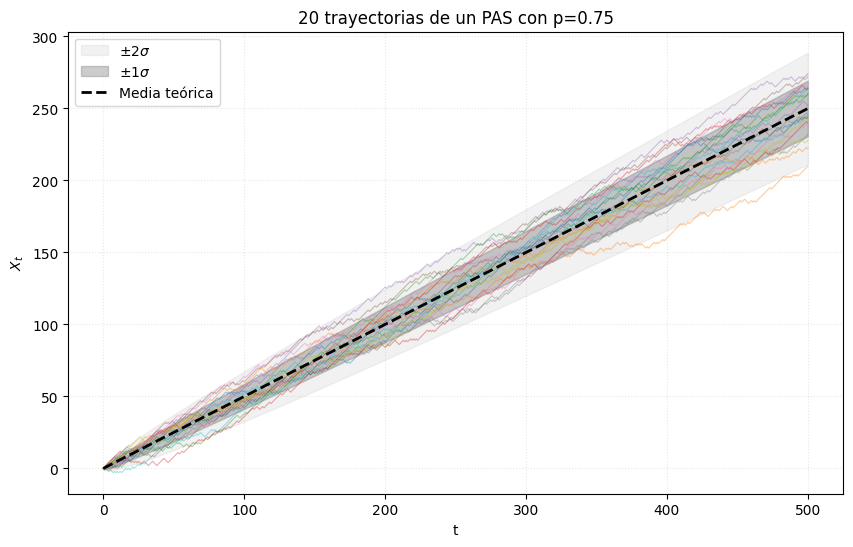

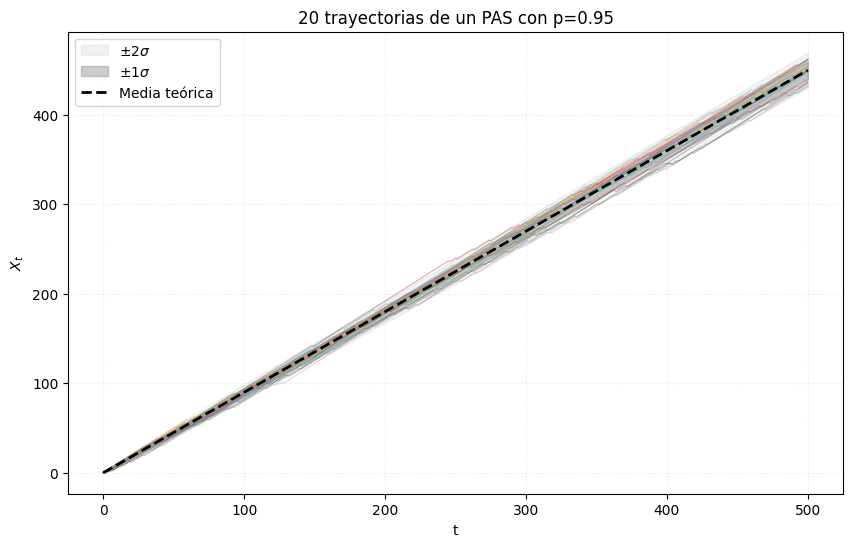

In [ ]:

# --- Visualización 2: Diapositivas 30, 31, 32 ---
escenarios_v2 = [0.5, 0.75, 0.95]
n_pasos = 500
n_reps = 20 # Ahora piden 20 trayectorias

t = np.arange(n_pasos + 1) # Array de tiempo [0, 1, 2, ..., 500]

for p in escenarios_v2:
    datos = simular_PAS(p, n_pasos, n_reps)

    # Cálculos teóricos
    media_teorica = (2*p - 1) * t
    desviacion_teorica = np.sqrt(4 * p * (1 - p) * t)

    plt.figure(figsize=(10, 6))

    # 1. Pintamos las 20 trayectorias (muy claritas)
    plt.plot(datos.T, lw=0.8, alpha=0.4)

   # 2. Pintamos la banda de ± 2 sigma (más ancha, gris claro)
    plt.fill_between(t, media_teorica - 2*desviacion_teorica, media_teorica + 2*desviacion_teorica,
                     color='lightgray', alpha=0.3, label=r'$\pm 2\sigma$')

    # 3. Pintamos la banda de ± 1 sigma (más estrecha, gris oscuro)
    plt.fill_between(t, media_teorica - desviacion_teorica, media_teorica + desviacion_teorica,
                     color='gray', alpha=0.4, label=r'$\pm 1\sigma$')

    # 4. Pintamos la línea de la media teórica
    plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2, label='Media teórica')

    plt.title(f'20 trayectorias de un PAS con p={p}')
    plt.xlabel('t')
    plt.ylabel('$X_t$')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.3)
    plt.show()


## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Escribir código para crear la imagen de la diapositiva 35.

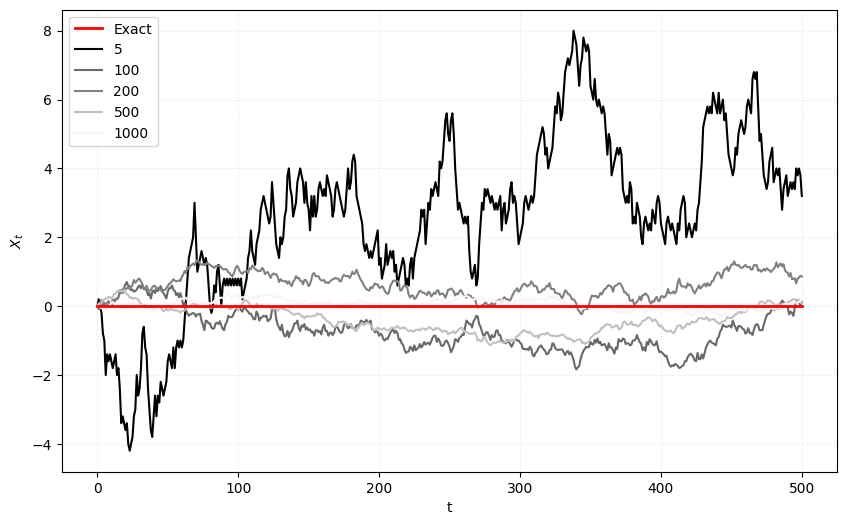

In [ ]:

# --- Visualización 3: Diapositiva 35 ---
n_pasos = 500
p_val = 0.5
t = np.arange(n_pasos + 1)
media_teorica = (2*p_val - 1) * t # Para p=0.5, esto es cero.

# Lista de cantidad de trayectorias a promediar
reps_lista = [5, 100, 200, 500, 1000]

plt.figure(figsize=(10, 6))

# Pintamos la media teórica (línea roja)
plt.plot(t, media_teorica, color='red', linewidth=2, label='Exact', zorder=10)

# Calculamos y pintamos las medias empíricas
# Usamos diferentes niveles de gris para imitar la gráfica original
colores_gris = ['black', 'dimgray', 'gray', 'silver', 'whitesmoke']

for i, reps in enumerate(reps_lista):
    datos = simular_PAS(p_val, n_pasos, reps)
    # Calculamos la media por columnas (el promedio de todas las trayectorias en cada instante)
    media_empirica = np.mean(datos, axis=0)

    plt.plot(t, media_empirica, color=colores_gris[i], label=f'{reps}')

plt.xlabel('t')
plt.ylabel('$X_t$')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.3)
plt.show()
